# Credit Valuation Adjustment dla kontraktów pochodnych

**Data wyceny:** 31.12.2025  
**Instrumenty:** FX Forward EUR/PLN oraz receiver IRS EUR EURIBOR 3M  
**Cel notebooka:** policzenie ekspozycji kredytowej, profili EE/PFE oraz CVA na poziomie pojedynczych transakcji i portfela, z uwzględnieniem nettingu, miesięcznej Variation Margin oraz wspólnej symulacji czynników ryzyka FX/IR.

Notebook jest uporządkowany zgodnie z etapami projektu:

1. analiza i wycena początkowa instrumentów,
2. bootstrap survival probabilities z kwotowań CDS,
3. symulacja i profil ekspozycji FX Forward,
4. symulacja i profil ekspozycji IRS,
5. kalkulacja CVA standalone i portfolio.


## 0. Importy, styl wykresów i parametry globalne

Wszystkie importy są zebrane w jednej komórce. Kolejna komórka ustawia spójny styl wizualny wykresów: biało-zielona paleta, delikatna siatka oraz formatowanie osi pod prezentację wyników ilościowych.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

from scipy.interpolate import interp1d

pd.set_option("display.float_format", "{:,.6f}".format)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [3]:
plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.edgecolor": "#CBD5D1",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#DDE7E2",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "lines.linewidth": 2.2,
    "font.family": "DejaVu Sans"
})

chart_colors = {
    "green": "#1F8A5B",
    "green_dark": "#176B47",
    "green_light": "#DCEFE7",
    "red": "#D92D20",
    "grey": "#667085",
    "grey_light": "#EAECF0",
    "blue": "#2563EB"
}

## 1. Dane wejściowe i parametry instrumentów

Analizowany portfel składa się z dwóch transakcji:

- **FX Forward:** kupno EUR i sprzedaż PLN, nominał 1 000 000 EUR, maturity 3Y, strike 4.4439.
- **Receiver IRS:** otrzymujemy fixed rate 2.02% rocznie i płacimy EURIBOR 3M kwartalnie, nominał 10 000 000 EUR, maturity 3Y.

Krzywe stóp są wprowadzone deterministycznie na podstawie danych projektowych. Discount factors są liczone przy założeniu continuous compounding:

$$
DF(0,T)=e^{-rT}
$$

Forward EUR/PLN jest wyznaczany z parytetu stóp procentowych:

$$
F_{0,T}=S_0\frac{DF_{EUR}(0,T)}{DF_{PLN}(0,T)}
$$


In [4]:
valuation_date = "2025-12-31"

fx_spot = 4.2166

fx_forward_notional_eur = 1_000_000
fx_forward_strike = 4.4439
fx_forward_maturity_years = 3.0

irs_notional_eur = 10_000_000
irs_fixed_rate = 0.0202
irs_maturity_years = 3.0
irs_fixed_leg_frequency = 1

eur_rate = 0.0200
pln_rate = 0.0375

recovery_rate = 0.40
lgd = 1.0 - recovery_rate

In [5]:
cds_quotes = pd.DataFrame({
    "tenor": ["6M", "1Y", "2Y", "3Y", "4Y", "5Y"],
    "maturity_months": [6, 12, 24, 36, 48, 60],
    "maturity_years": [0.5, 1.0, 2.0, 3.0, 4.0, 5.0],
    "spread_bps": [30.50, 39.40, 69.35, 96.70, 123.33, 152.07]
})

cds_quotes["spread"] = cds_quotes["spread_bps"] / 10_000

cds_quotes

,tenor,maturity_months,maturity_years,spread_bps,spread
0,6M,6,0.500000,30.500000,0.003050
1,1Y,12,1.000000,39.400000,0.003940
2,2Y,24,2.000000,69.350000,0.006935
3,3Y,36,3.000000,96.700000,0.009670
4,4Y,48,4.000000,123.330000,0.012333
5,5Y,60,5.000000,152.070000,0.015207


In [6]:
market_curve = pd.DataFrame({
    "month": np.arange(0, 61)
})

market_curve["time_years"] = market_curve["month"] / 12
market_curve["eur_rate"] = eur_rate
market_curve["pln_rate"] = pln_rate
market_curve["eur_df"] = np.exp(-eur_rate * market_curve["time_years"])
market_curve["pln_df"] = np.exp(-pln_rate * market_curve["time_years"])
market_curve["eurpln_forward"] = np.round(
    fx_spot * market_curve["eur_df"] / market_curve["pln_df"],
    4
)

market_curve.head(13)

,month,time_years,eur_rate,pln_rate,eur_df,pln_df,eurpln_forward
0,0,0.000000,0.020000,0.037500,1.000000,1.000000,4.216600
1,1,0.083333,0.020000,0.037500,0.998335,0.996880,4.222800
2,2,0.166667,0.020000,0.037500,0.996672,0.993769,4.228900
3,3,0.250000,0.020000,0.037500,0.995012,0.990669,4.235100
4,4,0.333333,0.020000,0.037500,0.993356,0.987578,4.241300
5,5,0.416667,0.020000,0.037500,0.991701,0.984496,4.247500
6,6,0.500000,0.020000,0.037500,0.990050,0.981425,4.253700
7,7,0.583333,0.020000,0.037500,0.988401,0.978363,4.259900
8,8,0.666667,0.020000,0.037500,0.986755,0.975310,4.266100
9,9,0.750000,0.020000,0.037500,0.985112,0.972267,4.272300


In [7]:
eur_df_curve = interp1d(
    market_curve["time_years"],
    market_curve["eur_df"],
    kind="linear",
    fill_value="extrapolate"
)

pln_df_curve = interp1d(
    market_curve["time_years"],
    market_curve["pln_df"],
    kind="linear",
    fill_value="extrapolate"
)

fx_forward_curve = interp1d(
    market_curve["time_years"],
    market_curve["eurpln_forward"],
    kind="linear",
    fill_value="extrapolate"
)

In [8]:
t = 3.0

pd.DataFrame({
    "metric": ["EUR DF", "PLN DF", "EURPLN Forward"],
    "value": [
        float(eur_df_curve(t)),
        float(pln_df_curve(t)),
        float(fx_forward_curve(t))
    ]
})

,metric,value
0,EUR DF,0.941765
1,PLN DF,0.893597
2,EURPLN Forward,4.443900


## 2. Wycena początkowa instrumentów

### FX Forward

Wartość kontraktu FX Forward w PLN liczona jest jako:

$$
MtM_{FX}(0)=N_{EUR}\cdot DF_{PLN}(0,T)\cdot\left(F_{0,T}-K\right)
$$

gdzie $K$ jest kursem strike, a $F_{0,T}$ kursem forward implied z krzywych EUR/PLN. Strike został zaokrąglony do 4 miejsc po przecinku, zgodnie z danymi projektowymi.


In [9]:
def price_fx_forward_pln(notional_eur, strike, maturity_years):
    forward = float(fx_forward_curve(maturity_years))
    df_pln = float(pln_df_curve(maturity_years))
    mtm_pln = notional_eur * df_pln * (forward - strike)

    return mtm_pln

In [10]:
fx_forward_mtm_0 = price_fx_forward_pln(
    notional_eur=fx_forward_notional_eur,
    strike=fx_forward_strike,
    maturity_years=fx_forward_maturity_years
)

fx_forward_mtm_0

0.0

### Receiver IRS — wycena kontrolna na dzień 0

Wycena startowa IRS służy jako kontrola spójności parametrów. Dla receiver IRS:

$$
MtM_{IRS}=PV_{fixed}-PV_{floating}
$$

Dla prostego testu startowego floating leg można zapisać jako:

$$
PV_{floating}=N\cdot\left(1-DF(0,T)\right)
$$

Natomiast w dalszej części, przy profilu ekspozycji IRS, stosowana jest pełna wycena cashflow-based z osobnymi przepływami fixed i floating.


In [11]:
irs_payment_times = np.arange(
    1 / irs_fixed_leg_frequency,
    irs_maturity_years + 1 / irs_fixed_leg_frequency,
    1 / irs_fixed_leg_frequency
)

irs_payment_times

array([1., 2., 3.])

In [12]:
def price_receiver_irs_eur(notional_eur, fixed_rate, payment_times):
    dfs = np.array([float(eur_df_curve(t)) for t in payment_times])
    accruals = np.diff(np.insert(payment_times, 0, 0.0))

    fixed_leg_pv = notional_eur * fixed_rate * np.sum(accruals * dfs)
    floating_leg_pv = notional_eur * (1.0 - dfs[-1])
    mtm_eur = fixed_leg_pv - floating_leg_pv

    return mtm_eur

In [13]:
irs_mtm_0_eur = price_receiver_irs_eur(
    notional_eur=irs_notional_eur,
    fixed_rate=irs_fixed_rate,
    payment_times=irs_payment_times
)

irs_mtm_0_pln = irs_mtm_0_eur * fx_spot

pd.DataFrame({
    "metric": ["IRS MtM EUR", "IRS MtM PLN"],
    "value": [irs_mtm_0_eur, irs_mtm_0_pln]
})

,metric,value
0,IRS MtM EUR,-38.629657
1,IRS MtM PLN,-162.885811


In [14]:
irs_dfs = np.array([float(eur_df_curve(t)) for t in irs_payment_times])
irs_accruals = np.diff(np.insert(irs_payment_times, 0, 0.0))

irs_annuity = np.sum(irs_accruals * irs_dfs)
irs_par_rate = (1.0 - irs_dfs[-1]) / irs_annuity

pd.DataFrame({
    "metric": [
        "IRS fixed rate",
        "IRS par rate",
        "Difference fixed - par",
        "IRS annuity",
        "PV fixed leg EUR",
        "PV floating leg EUR",
        "IRS MtM EUR"
    ],
    "value": [
        irs_fixed_rate,
        irs_par_rate,
        irs_fixed_rate - irs_par_rate,
        irs_annuity,
        irs_notional_eur * irs_fixed_rate * irs_annuity,
        irs_notional_eur * (1.0 - irs_dfs[-1]),
        irs_mtm_0_eur
    ]
})

,metric,value
0,IRS fixed rate,0.020200
1,IRS par rate,0.020201
2,Difference fixed - par,-0.000001
3,IRS annuity,2.882753
4,PV fixed leg EUR,"582,316.034501"
5,PV floating leg EUR,"582,354.664158"
6,IRS MtM EUR,-38.629657


## 3. Bootstrap survival probabilities z CDS

Etap kredytowy opiera się na kwotowaniach CDS. Zakładamy recovery rate $R=40\%$, czyli:

$$
LGD=1-R=60\%
$$

Bootstrap jest przeprowadzony po **piecewise-constant hazard rates**. Survival probability dla miesiąca $t$ jest liczona jako:

$$
PS(t)=\exp\left(-\int_0^t \lambda(s)ds\right)
$$

Dla CDS w punkcie kalibracyjnym zachodzi równość premium leg i default leg:

$$
PL_N=DL_N
$$

Premium leg:

$$
PL_N=S_N\sum_{n=1}^{N}DF(0,T_n)\cdot PS(T_n)\cdot \Delta t_n
$$

Default leg:

$$
DL_N=LGD\sum_{n=1}^{N}DF(0,T_n)\cdot\left(PS(T_{n-1})-PS(T_n)\right)
$$

Modelowy spread CDS wynika więc z:

$$
S_N=\frac{LGD\sum_{n=1}^{N}DF(0,T_n)\cdot\left(PS(T_{n-1})-PS(T_n)\right)}{\sum_{n=1}^{N}DF(0,T_n)\cdot PS(T_n)\cdot\Delta t_n}
$$


In [15]:
premium_freq_months = 3
default_grid_step_months = 1
max_cds_maturity_months = int(cds_quotes["maturity_months"].max())

cds_discount_factors = market_curve.set_index("month")["eur_df"].to_dict()

pd.DataFrame({
    "parameter": [
        "Premium frequency months",
        "Default grid step months",
        "Max CDS maturity months",
        "Recovery rate",
        "LGD"
    ],
    "value": [
        premium_freq_months,
        default_grid_step_months,
        max_cds_maturity_months,
        recovery_rate,
        lgd
    ]
})

,parameter,value
0,Premium frequency months,3.000000
1,Default grid step months,1.000000
2,Max CDS maturity months,60.000000
3,Recovery rate,0.400000
4,LGD,0.600000


In [16]:
def survival_probability(month, hazard_rates, interval_ends):
    cumulative_hazard = 0.0
    start_month = 0

    for hazard_rate, end_month in zip(hazard_rates, interval_ends):
        if month <= start_month:
            break

        covered_months = min(month, end_month) - start_month

        if covered_months > 0:
            cumulative_hazard += hazard_rate * covered_months / 12.0

        if month <= end_month:
            break

        start_month = end_month

    return np.exp(-cumulative_hazard)

In [17]:
def default_leg(
    maturity_months,
    lgd,
    hazard_rates,
    interval_ends,
    default_grid_step_months,
    discount_factors
):
    pv = 0.0

    for month in range(default_grid_step_months, maturity_months + 1, default_grid_step_months):
        df = discount_factors[month]
        ps_prev = survival_probability(month - default_grid_step_months, hazard_rates, interval_ends)
        ps_curr = survival_probability(month, hazard_rates, interval_ends)
        pv += lgd * df * (ps_prev - ps_curr)

    return pv

In [18]:
def model_cds_spread(
    maturity_months,
    hazard_rates,
    interval_ends,
    premium_freq_months,
    default_grid_step_months,
    lgd,
    discount_factors
):
    risky_annuity = 0.0

    for month in range(premium_freq_months, maturity_months + 1, premium_freq_months):
        df = discount_factors[month]
        ps = survival_probability(month, hazard_rates, interval_ends)
        accrual = premium_freq_months / 12.0
        risky_annuity += df * ps * accrual

    protection_leg = default_leg(
        maturity_months=maturity_months,
        lgd=lgd,
        hazard_rates=hazard_rates,
        interval_ends=interval_ends,
        default_grid_step_months=default_grid_step_months,
        discount_factors=discount_factors
    )

    return protection_leg / risky_annuity

In [19]:
def bisection_solve(fn, low=1e-8, high=5.0, tol=1e-12, max_iter=200):
    f_low = fn(low)
    f_high = fn(high)

    expand_iter = 0

    while f_low * f_high > 0 and expand_iter < 50:
        high *= 2.0
        f_high = fn(high)
        expand_iter += 1

    if f_low * f_high > 0:
        raise RuntimeError("Bisection bracket not found")

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        f_mid = fn(mid)

        if abs(f_mid) < tol or (high - low) < tol:
            return mid

        if f_low * f_mid <= 0:
            high = mid
            f_high = f_mid
        else:
            low = mid
            f_low = f_mid

    return 0.5 * (low + high)

In [20]:
hazard_rates = []
interval_ends = []
calibration_rows = []

for row in cds_quotes.itertuples(index=False):
    tenor = row.tenor
    maturity_months = int(row.maturity_months)
    market_spread = float(row.spread)

    def objective(hazard_rate):
        trial_hazard_rates = hazard_rates + [hazard_rate]
        trial_interval_ends = interval_ends + [maturity_months]

        fitted_spread = model_cds_spread(
            maturity_months=maturity_months,
            hazard_rates=trial_hazard_rates,
            interval_ends=trial_interval_ends,
            premium_freq_months=premium_freq_months,
            default_grid_step_months=default_grid_step_months,
            lgd=lgd,
            discount_factors=cds_discount_factors
        )

        return fitted_spread - market_spread

    calibrated_hazard_rate = bisection_solve(objective)

    hazard_rates.append(calibrated_hazard_rate)
    interval_ends.append(maturity_months)

    fitted_spread = model_cds_spread(
        maturity_months=maturity_months,
        hazard_rates=hazard_rates,
        interval_ends=interval_ends,
        premium_freq_months=premium_freq_months,
        default_grid_step_months=default_grid_step_months,
        lgd=lgd,
        discount_factors=cds_discount_factors
    )

    calibration_rows.append({
        "tenor": tenor,
        "maturity_months": maturity_months,
        "market_spread_bps": market_spread * 10_000,
        "model_spread_bps": fitted_spread * 10_000,
        "fit_error_bps": (fitted_spread - market_spread) * 10_000,
        "hazard_rate": calibrated_hazard_rate
    })

cds_bootstrap_results = pd.DataFrame(calibration_rows)

cds_bootstrap_results

,tenor,maturity_months,market_spread_bps,model_spread_bps,fit_error_bps,hazard_rate
0,6M,6,30.500000,30.500000,0.000000,0.005072
1,1Y,12,39.400000,39.400000,-0.000000,0.008049
2,2Y,24,69.350000,69.350000,-0.000000,0.016656
3,3Y,36,96.700000,96.700000,-0.000000,0.025662
4,4Y,48,123.330000,123.330000,-0.000000,0.034929
5,5Y,60,152.070000,152.070000,0.000000,0.046842


### Miesięczna krzywa default probabilities

Po kalibracji hazard rates generowana jest miesięczna tabela zawierająca:

- survival probability $PS(t)$,
- cumulative default probability $1-PS(t)$,
- marginal default probability:

$$
q(t_{i-1},t_i)=PS(t_{i-1})-PS(t_i)
$$

Ta tabela jest później bezpośrednim wejściem do kalkulacji CVA.


In [21]:
survival_rows = []

for month in range(0, max_cds_maturity_months + 1):
    ps = survival_probability(
        month=month,
        hazard_rates=hazard_rates,
        interval_ends=interval_ends
    )

    survival_rows.append({
        "month": month,
        "time_years": month / 12,
        "survival_probability": ps
    })

survival_table = pd.DataFrame(survival_rows)

survival_table["cumulative_default_probability"] = (
    1.0 - survival_table["survival_probability"]
)

survival_table["marginal_default_probability"] = (
    survival_table["survival_probability"].shift(1)
    - survival_table["survival_probability"]
)

survival_table.loc[0, "marginal_default_probability"] = 0.0

survival_table.head(13)

,month,time_years,survival_probability,cumulative_default_probability,marginal_default_probability
0,0,0.000000,1.000000,0.000000,0.000000
1,1,0.083333,0.999577,0.000423,0.000423
2,2,0.166667,0.999155,0.000845,0.000422
3,3,0.250000,0.998733,0.001267,0.000422
4,4,0.333333,0.998311,0.001689,0.000422
5,5,0.416667,0.997889,0.002111,0.000422
6,6,0.500000,0.997467,0.002533,0.000422
7,7,0.583333,0.996799,0.003201,0.000669
8,8,0.666667,0.996130,0.003870,0.000668
9,9,0.750000,0.995462,0.004538,0.000668


In [22]:
survival_table.loc[
    survival_table["month"].isin(cds_quotes["maturity_months"]),
    [
        "month",
        "time_years",
        "survival_probability",
        "cumulative_default_probability",
        "marginal_default_probability"
    ]
]

,month,time_years,survival_probability,cumulative_default_probability,marginal_default_probability
6,6,0.500000,0.997467,0.002533,0.000422
12,12,1.000000,0.993461,0.006539,0.000667
24,24,2.000000,0.977051,0.022949,0.001357
36,36,3.000000,0.952297,0.047703,0.002039
48,48,4.000000,0.919609,0.080391,0.002681
60,60,5.000000,0.877526,0.122474,0.003432


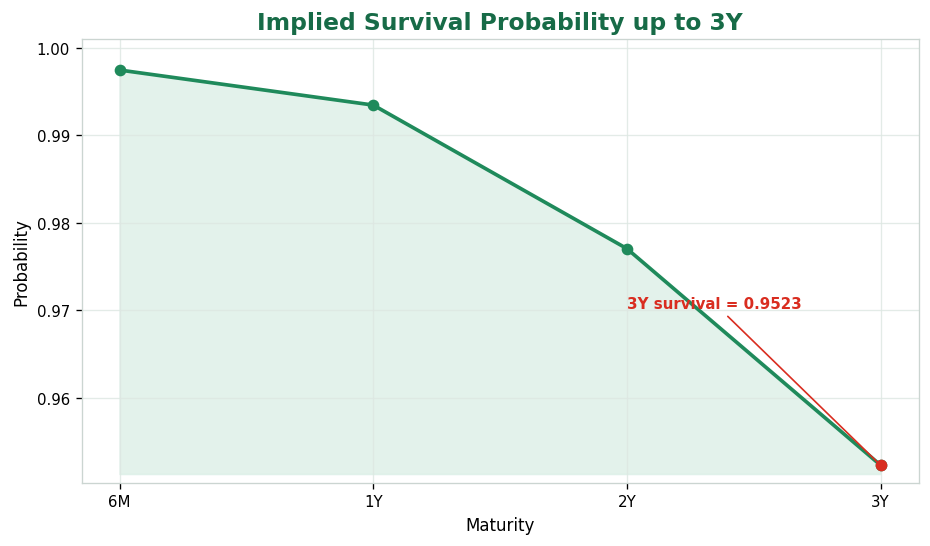

In [23]:
cds_plot_points = survival_table.loc[
    survival_table["month"].isin([6, 12, 24, 36]),
    ["month", "time_years", "survival_probability", "cumulative_default_probability"]
].copy()

cds_plot_points["label"] = ["6M", "1Y", "2Y", "3Y"]

x = np.arange(len(cds_plot_points))
y = cds_plot_points["survival_probability"].to_numpy()

plt.figure(figsize=(9, 4.8))

plt.plot(
    x,
    y,
    marker="o",
    color=chart_colors["green"],
    markerfacecolor=chart_colors["green"],
    markeredgecolor=chart_colors["green"]
)

plt.fill_between(
    x,
    y,
    y.min() - 0.001,
    color=chart_colors["green_light"],
    alpha=0.8
)

plt.scatter(
    x[-1],
    y[-1],
    color=chart_colors["red"],
    zorder=5
)

plt.annotate(
    f"3Y survival = {y[-1]:.4f}",
    xy=(x[-1], y[-1]),
    xytext=(x[-1] - 1.0, y[-1] + 0.018),
    arrowprops=dict(arrowstyle="-", color=chart_colors["red"], lw=1),
    color=chart_colors["red"],
    fontsize=9,
    fontweight="bold"
)

plt.xticks(x, cds_plot_points["label"])
plt.xlabel("Maturity")
plt.ylabel("Probability")
plt.title("Implied Survival Probability up to 3Y", color=chart_colors["green_dark"])
plt.ylim(y.min() - 0.002, 1.001)
plt.show()

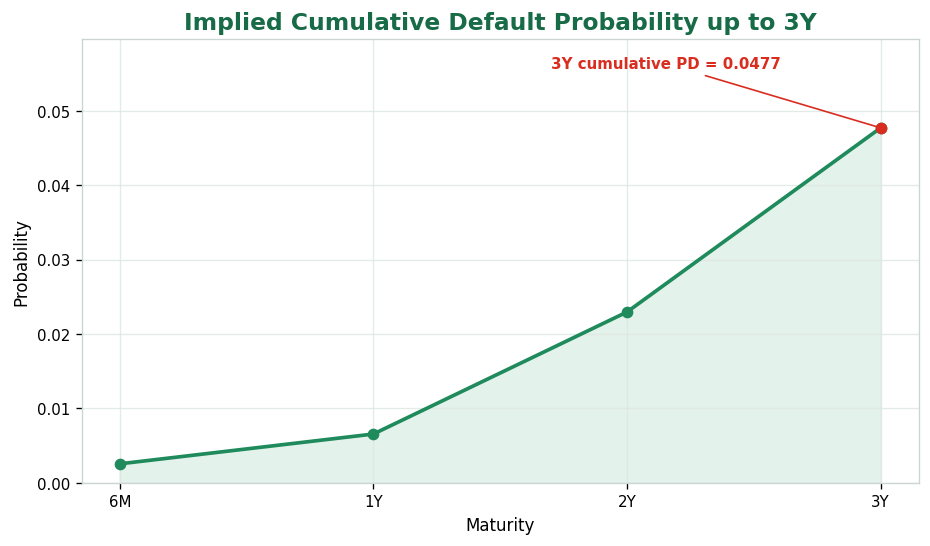

In [24]:
x = np.arange(len(cds_plot_points))
y = cds_plot_points["cumulative_default_probability"].to_numpy()

plt.figure(figsize=(9, 4.8))

plt.plot(
    x,
    y,
    marker="o",
    color=chart_colors["green"],
    markerfacecolor=chart_colors["green"],
    markeredgecolor=chart_colors["green"]
)

plt.fill_between(
    x,
    y,
    0,
    color=chart_colors["green_light"],
    alpha=0.8
)

plt.scatter(
    x[-1],
    y[-1],
    color=chart_colors["red"],
    zorder=5
)

plt.annotate(
    f"3Y cumulative PD = {y[-1]:.4f}",
    xy=(x[-1], y[-1]),
    xytext=(x[-1] - 1.3, y[-1] + 0.008),
    arrowprops=dict(arrowstyle="-", color=chart_colors["red"], lw=1),
    color=chart_colors["red"],
    fontsize=9,
    fontweight="bold"
)

plt.xticks(x, cds_plot_points["label"])
plt.xlabel("Maturity")
plt.ylabel("Probability")
plt.title("Implied Cumulative Default Probability up to 3Y", color=chart_colors["green_dark"])
plt.ylim(0, y[-1] * 1.25)
plt.show()

## 4. Symulacja czynników ryzyka i ekspozycja FX Forward

Zmienność EUR/PLN jest kalibrowana z historycznych danych Stooq na bazie dziennych log-zwrotów:

$$
r_t=\ln\left(\frac{S_t}{S_{t-1}}\right)
$$

Roczna zmienność FX:

$$
\sigma_{FX,annual}=std(r_t)\sqrt{252}
$$

FX jest modelowany za pomocą Geometric Brownian Motion:

$$
dS_t=S_t\mu dt+\sigma S_t dW_t
$$

W dyskretnym kroku miesięcznym:

$$
S_{t+\Delta t}=S_t\exp\left((\mu-\frac{1}{2}\sigma^2)\Delta t+\sigma\sqrt{\Delta t}Z_t\right)
$$

Drift FX ustawiony jest zgodnie z różnicą stóp PLN i EUR:

$$
\mu=r_{PLN}-r_{EUR}
$$


In [25]:
fx_history_path = "../data/eurpln_d.csv"

fx_history = pd.read_csv(fx_history_path)

fx_history = fx_history.rename(columns={
    "Data": "date",
    "Otwarcie": "open",
    "Najwyzszy": "high",
    "Najnizszy": "low",
    "Zamkniecie": "close"
})

fx_history["date"] = pd.to_datetime(fx_history["date"])
fx_history = fx_history.sort_values("date").reset_index(drop=True)

fx_history["log_return"] = np.log(
    fx_history["close"] / fx_history["close"].shift(1)
)

fx_daily_volatility = fx_history["log_return"].std(ddof=1)
fx_volatility = fx_daily_volatility * np.sqrt(252)

pd.DataFrame({
    "metric": [
        "First observation date",
        "Last observation date",
        "Number of observations",
        "FX spot from market data",
        "Last historical close",
        "Daily volatility",
        "Annual volatility"
    ],
    "value": [
        fx_history["date"].min(),
        fx_history["date"].max(),
        len(fx_history),
        fx_spot,
        fx_history["close"].iloc[-1],
        fx_daily_volatility,
        fx_volatility
    ]
})

,metric,value
0,First observation date,2022-01-03 00:00:00
1,Last observation date,2025-12-31 00:00:00
2,Number of observations,1034
3,FX spot from market data,4.216600
4,Last historical close,4.216610
5,Daily volatility,0.003840
6,Annual volatility,0.060954


In [26]:
simulation_horizon_years = 3.0
simulation_step_years = 1 / 12
simulation_months = int(simulation_horizon_years * 12)
n_simulations = 10_000

fx_drift = pln_rate - eur_rate

time_grid = np.arange(0, simulation_months + 1) * simulation_step_years

pd.DataFrame({
    "parameter": [
        "Simulation horizon years",
        "Simulation step years",
        "Simulation months",
        "Number of simulations",
        "FX spot",
        "FX strike",
        "FX drift",
        "FX volatility"
    ],
    "value": [
        simulation_horizon_years,
        simulation_step_years,
        simulation_months,
        n_simulations,
        fx_spot,
        fx_forward_strike,
        fx_drift,
        fx_volatility
    ]
})

,parameter,value
0,Simulation horizon years,3.000000
1,Simulation step years,0.083333
2,Simulation months,36.000000
3,Number of simulations,"10,000.000000"
4,FX spot,4.216600
5,FX strike,4.443900
6,FX drift,0.017500
7,FX volatility,0.060954


## 5. Kalibracja stopy EUR i wspólna symulacja FX/IR

Zmienność stopy EURIBOR 3M jest kalibrowana na dziennych zmianach stopy:

$$
\Delta r_t=r_t-r_{t-1}
$$

Roczna zmienność stopy:

$$
\sigma_{IR,annual}=std(\Delta r_t)\sqrt{252}
$$

Stopa EUR jest modelowana przez Arithmetic Brownian Motion:

$$
dr_t=\mu dt+\sigma dW_t
$$

czyli w kroku dyskretnym:

$$
r_{t+\Delta t}=r_t+\mu\Delta t+\sigma\sqrt{\Delta t}Z_t
$$


In [27]:
euribor_path = "../data/euribor_3m_daily.csv"

euribor_raw = pd.read_csv(
    euribor_path,
    skiprows=9,
    header=None,
    names=["date", "rate_percent", "flag"]
)

euribor_history = euribor_raw.loc[
    euribor_raw["rate_percent"] != ".",
    ["date", "rate_percent"]
].copy()

euribor_history["date"] = pd.to_datetime(euribor_history["date"])
euribor_history["rate"] = pd.to_numeric(euribor_history["rate_percent"]) / 100
euribor_history = euribor_history.sort_values("date").reset_index(drop=True)

euribor_history["rate_change"] = euribor_history["rate"].diff()

ir_daily_volatility = euribor_history["rate_change"].std(ddof=1)
ir_volatility = ir_daily_volatility * np.sqrt(252)

pd.DataFrame({
    "metric": [
        "First observation date",
        "Last observation date",
        "Number of observations",
        "Initial market EUR rate",
        "Last historical Euribor 3M",
        "Daily IR volatility",
        "Annual IR volatility"
    ],
    "value": [
        euribor_history["date"].min(),
        euribor_history["date"].max(),
        len(euribor_history),
        eur_rate,
        euribor_history["rate"].iloc[-1],
        ir_daily_volatility,
        ir_volatility
    ]
})

,metric,value
0,First observation date,2024-01-02 00:00:00
1,Last observation date,2026-05-21 00:00:00
2,Number of observations,608
3,Initial market EUR rate,0.020000
4,Last historical Euribor 3M,0.021950
5,Daily IR volatility,0.000183
6,Annual IR volatility,0.002898


In [28]:
ir_initial_rate = eur_rate
ir_drift = 0.0

irs_simulation_payment_times = irs_payment_times.copy()

pd.DataFrame({
    "parameter": [
        "Initial EUR rate",
        "IR drift",
        "IR volatility",
        "IRS notional EUR",
        "IRS fixed rate",
        "IRS maturity years",
        "Number of simulations",
        "Simulation months"
    ],
    "value": [
        ir_initial_rate,
        ir_drift,
        ir_volatility,
        irs_notional_eur,
        irs_fixed_rate,
        irs_maturity_years,
        n_simulations,
        simulation_months
    ]
})

,parameter,value
0,Initial EUR rate,0.020000
1,IR drift,0.000000
2,IR volatility,0.002898
3,IRS notional EUR,"10,000,000.000000"
4,IRS fixed rate,0.020200
5,IRS maturity years,3.000000
6,Number of simulations,"10,000.000000"
7,Simulation months,36.000000


### Korelacja FX/IR i dekompozycja Cholesky

Wymaganie projektowe zakłada wspólną symulację dwóch procesów z korelacją między czynnikami ryzyka. Korelacja jest estymowana z części wspólnej danych historycznych FX i EURIBOR 3M:

$$
\rho_{FX,IR}=Corr(r^{FX}_t,\Delta r^{IR}_t)
$$

Następnie generowane są dwa skorelowane szoki normalne z wykorzystaniem dekompozycji Cholesky:

$$
C=LL^T
$$

$$
Z^{corr}=Z^{ind}L^T
$$

Wspólna symulacja jest kluczowa dla prawidłowego liczenia nettingu, Variation Margin oraz CVA portfelowego w PLN.


In [29]:
fx_ir_correlation_data = fx_history[
    ["date", "log_return"]
].merge(
    euribor_history[["date", "rate_change"]],
    on="date",
    how="inner"
).dropna()

fx_ir_correlation = fx_ir_correlation_data["log_return"].corr(
    fx_ir_correlation_data["rate_change"]
)

pd.DataFrame({
    "metric": [
        "Common observations",
        "FX / IR historical correlation"
    ],
    "value": [
        len(fx_ir_correlation_data),
        fx_ir_correlation
    ]
})

,metric,value
0,Common observations,510.000000
1,FX / IR historical correlation,0.079591


In [30]:
rho_fx_ir = fx_ir_correlation

correlation_matrix = np.array([
    [1.0, rho_fx_ir],
    [rho_fx_ir, 1.0]
])

cholesky_matrix = np.linalg.cholesky(correlation_matrix)

local_rng = np.random.default_rng(RANDOM_SEED)

independent_normals = local_rng.standard_normal(
    size=(n_simulations, simulation_months, 2)
)

correlated_normals = independent_normals @ cholesky_matrix.T

z_fx = correlated_normals[:, :, 0]
z_ir = correlated_normals[:, :, 1]

fx_paths = np.zeros((n_simulations, simulation_months + 1))
ir_paths = np.zeros((n_simulations, simulation_months + 1))

fx_paths[:, 0] = fx_spot
ir_paths[:, 0] = ir_initial_rate

for month in range(1, simulation_months + 1):
    fx_paths[:, month] = fx_paths[:, month - 1] * np.exp(
        (fx_drift - 0.5 * fx_volatility ** 2) * simulation_step_years
        + fx_volatility * np.sqrt(simulation_step_years) * z_fx[:, month - 1]
    )

    ir_paths[:, month] = (
        ir_paths[:, month - 1]
        + ir_drift * simulation_step_years
        + ir_volatility * np.sqrt(simulation_step_years) * z_ir[:, month - 1]
    )

pd.DataFrame({
    "metric": [
        "Historical FX / IR correlation",
        "Simulated shocks correlation",
        "FX paths shape",
        "IR paths shape"
    ],
    "value": [
        rho_fx_ir,
        np.corrcoef(z_fx.ravel(), z_ir.ravel())[0, 1],
        str(fx_paths.shape),
        str(ir_paths.shape)
    ]
})

,metric,value
0,Historical FX / IR correlation,0.079591
1,Simulated shocks correlation,0.080089
2,FX paths shape,"(10000, 37)"
3,IR paths shape,"(10000, 37)"


### Walidacja symulacji FX

Sprawdzamy, czy symulacja GBM odtwarza teoretyczną średnią i wariancję:

$$
E[S_t]=S_0e^{\mu t}
$$

$$
Var(S_t)=S_0^2e^{2\mu t}\left(e^{\sigma^2t}-1\right)
$$

Walidacja jest istotna, ponieważ profile exposure i CVA są wrażliwe na jakość symulacji Monte Carlo.


In [31]:
fx_empirical_mean = fx_paths.mean(axis=0)
fx_theoretical_mean = fx_spot * np.exp(fx_drift * time_grid)

fx_mean_validation = pd.DataFrame({
    "month": np.arange(0, simulation_months + 1),
    "time_years": time_grid,
    "empirical_mean": fx_empirical_mean,
    "theoretical_mean": fx_theoretical_mean,
    "relative_error": (
        fx_empirical_mean - fx_theoretical_mean
    ) / fx_theoretical_mean
})

fx_mean_validation.tail()

,month,time_years,empirical_mean,theoretical_mean,relative_error
32,32,2.666667,4.412746,4.418038,-0.001198
33,33,2.750000,4.419743,4.424486,-0.001072
34,34,2.833333,4.426212,4.430943,-0.001068
35,35,2.916667,4.431481,4.437410,-0.001336
36,36,3.000000,4.437203,4.443886,-0.001504


In [32]:
fx_empirical_variance = fx_paths.var(axis=0, ddof=1)

fx_theoretical_variance = (
    fx_spot ** 2
    * np.exp(2 * fx_drift * time_grid)
    * (np.exp(fx_volatility ** 2 * time_grid) - 1)
)

fx_variance_relative_error = np.zeros_like(fx_theoretical_variance)

valid_variance_mask = fx_theoretical_variance > 0

fx_variance_relative_error[valid_variance_mask] = (
    fx_empirical_variance[valid_variance_mask]
    - fx_theoretical_variance[valid_variance_mask]
) / fx_theoretical_variance[valid_variance_mask]

fx_variance_validation = pd.DataFrame({
    "month": np.arange(0, simulation_months + 1),
    "time_years": time_grid,
    "empirical_variance": fx_empirical_variance,
    "theoretical_variance": fx_theoretical_variance,
    "relative_error": fx_variance_relative_error
})

fx_variance_validation.tail()

,month,time_years,empirical_variance,theoretical_variance,relative_error
32,32,2.666667,0.193823,0.194349,-0.002711
33,33,2.750000,0.200395,0.201039,-0.003206
34,34,2.833333,0.206885,0.207769,-0.004254
35,35,2.916667,0.213130,0.214538,-0.006562
36,36,3.000000,0.220191,0.221346,-0.005221


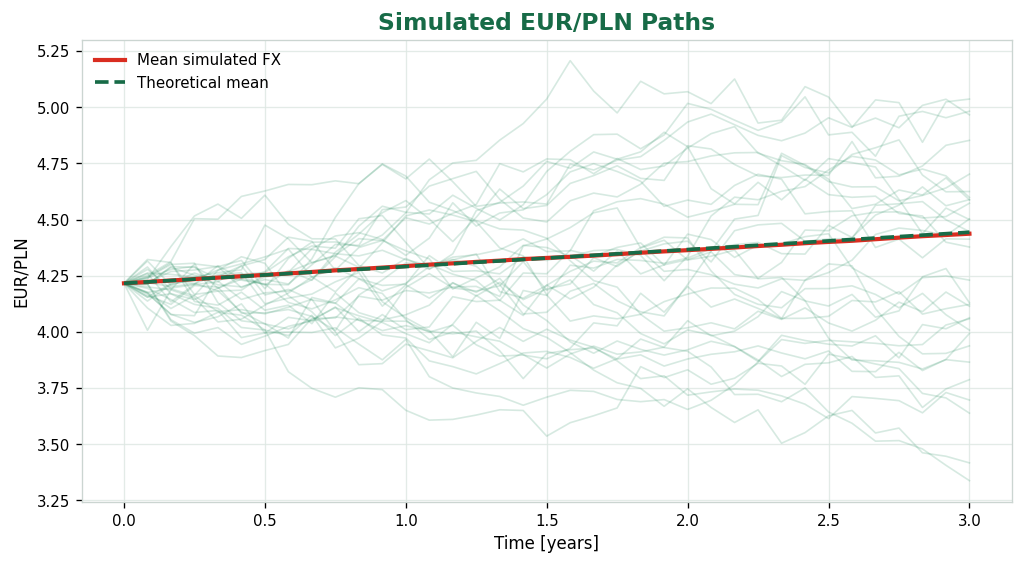

In [33]:
plt.figure(figsize=(10, 5))

for path_id in range(30):
    plt.plot(
        time_grid,
        fx_paths[path_id],
        color=chart_colors["green"],
        alpha=0.18,
        linewidth=1.0
    )

plt.plot(
    time_grid,
    fx_empirical_mean,
    color=chart_colors["red"],
    linewidth=2.5,
    label="Mean simulated FX"
)

plt.plot(
    time_grid,
    fx_theoretical_mean,
    color=chart_colors["green_dark"],
    linewidth=2.2,
    linestyle="--",
    label="Theoretical mean"
)

plt.xlabel("Time [years]")
plt.ylabel("EUR/PLN")
plt.title("Simulated EUR/PLN Paths", color=chart_colors["green_dark"])
plt.legend()
plt.show()

### Exposure FX Forward

Dla każdej ścieżki i każdego miesiąca wyznaczany jest pathwise MtM FX Forwarda:

$$
MtM_{FX}(t)=N_{EUR}\cdot DF_{PLN}(t,T)\cdot(F_{t,T}-K)
$$

gdzie:

$$
F_{t,T}=S_t\frac{DF_{EUR}(t,T)}{DF_{PLN}(t,T)}
$$

Ekspozycja kredytowa jest dodatnią częścią MtM:

$$
E_{FX}(t)=\max(MtM_{FX}(t),0)
$$

Expected Exposure oraz PFE są liczone po przekroju symulacji:

$$
EE(t)=E\left[\max(MtM(t),0)\right]
$$


In [34]:
fx_forward_mtm_paths = np.zeros_like(fx_paths)

for month in range(simulation_months + 1):
    t = month / 12
    remaining_maturity = max(fx_forward_maturity_years - t, 0.0)

    df_eur_remaining = np.exp(-eur_rate * remaining_maturity)
    df_pln_remaining = np.exp(-pln_rate * remaining_maturity)

    forward_t = fx_paths[:, month] * df_eur_remaining / df_pln_remaining

    fx_forward_mtm_paths[:, month] = (
        fx_forward_notional_eur
        * df_pln_remaining
        * (forward_t - fx_forward_strike)
    )

fx_forward_exposure_paths = np.maximum(fx_forward_mtm_paths, 0.0)

pd.DataFrame({
    "metric": [
        "Initial FX Forward MtM",
        "Initial FX Forward Exposure",
        "Final mean MtM",
        "Final mean exposure"
    ],
    "value": [
        fx_forward_mtm_paths[:, 0].mean(),
        fx_forward_exposure_paths[:, 0].mean(),
        fx_forward_mtm_paths[:, -1].mean(),
        fx_forward_exposure_paths[:, -1].mean()
    ]
})

,metric,value
0,Initial FX Forward MtM,-12.918504
1,Initial FX Forward Exposure,0.000000
2,Final mean MtM,"-6,697.488014"
3,Final mean exposure,"183,059.828254"


In [35]:
fx_ee_profile = fx_forward_exposure_paths.mean(axis=0)
fx_pfe_95_profile = np.quantile(fx_forward_exposure_paths, 0.95, axis=0)
fx_pfe_99_profile = np.quantile(fx_forward_exposure_paths, 0.99, axis=0)

fx_exposure_profile = pd.DataFrame({
    "month": np.arange(0, simulation_months + 1),
    "time_years": time_grid,
    "expected_exposure": fx_ee_profile,
    "pfe_95": fx_pfe_95_profile,
    "pfe_99": fx_pfe_99_profile
})

fx_exposure_profile.tail()

,month,time_years,expected_exposure,pfe_95,pfe_99
32,32,2.666667,"170,611.774652","762,996.757097","1,117,496.109229"
33,33,2.750000,"174,336.881776","777,423.852773","1,155,367.554354"
34,34,2.833333,"177,415.425535","783,679.936836","1,177,091.977351"
35,35,2.916667,"179,999.560895","801,729.048927","1,200,428.289583"
36,36,3.000000,"183,059.828254","809,843.533109","1,232,836.410613"


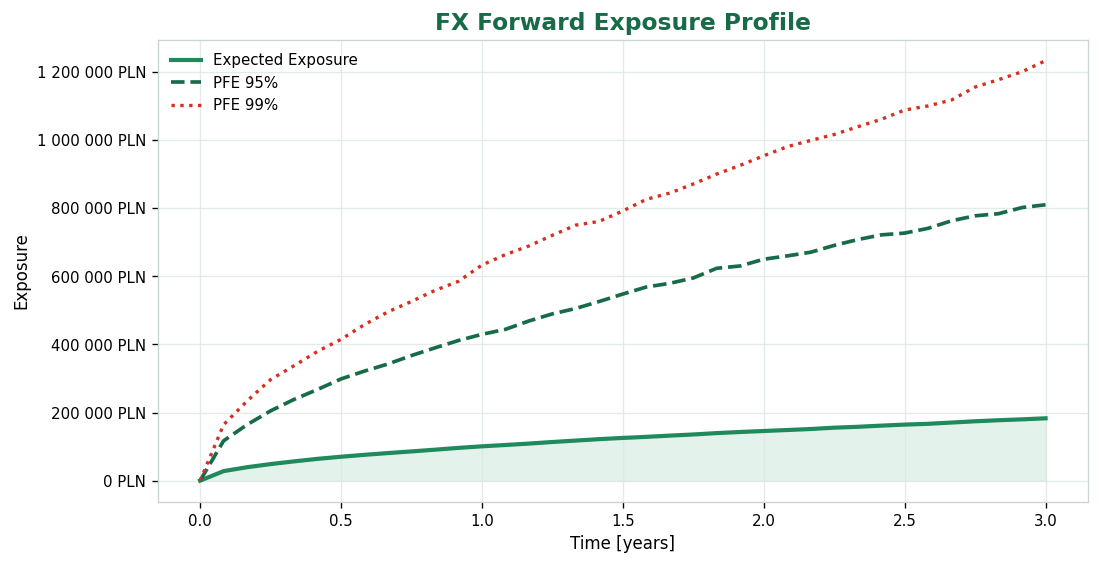

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    fx_exposure_profile["time_years"],
    fx_exposure_profile["expected_exposure"],
    color=chart_colors["green"],
    linewidth=2.5,
    label="Expected Exposure"
)

plt.plot(
    fx_exposure_profile["time_years"],
    fx_exposure_profile["pfe_95"],
    color=chart_colors["green_dark"],
    linewidth=2.2,
    linestyle="--",
    label="PFE 95%"
)

plt.plot(
    fx_exposure_profile["time_years"],
    fx_exposure_profile["pfe_99"],
    color=chart_colors["red"],
    linewidth=2.0,
    linestyle=":",
    label="PFE 99%"
)

plt.fill_between(
    fx_exposure_profile["time_years"],
    fx_exposure_profile["expected_exposure"],
    0,
    color=chart_colors["green_light"],
    alpha=0.8
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f} PLN".replace(",", " "))
)

plt.xlabel("Time [years]")
plt.ylabel("Exposure")
plt.title("FX Forward Exposure Profile", color=chart_colors["green_dark"])
plt.legend()
plt.show()

In [37]:
fx_exposure_key_points = fx_exposure_profile.loc[
    fx_exposure_profile["month"].isin([6, 12, 24, 36]),
    [
        "month",
        "time_years",
        "expected_exposure",
        "pfe_95",
        "pfe_99"
    ]
].copy()

fx_exposure_key_points

,month,time_years,expected_exposure,pfe_95,pfe_99
6,6,0.500000,"70,243.963912","298,605.374436","414,815.791406"
12,12,1.000000,"100,837.110535","429,506.196164","632,869.918603"
24,24,2.000000,"145,817.017323","650,045.653961","953,608.267722"
36,36,3.000000,"183,059.828254","809,843.533109","1,232,836.410613"


## 6. IRS Expected Exposure

IRS jest wyceniany metodą cashflow-based. W odróżnieniu od uproszczonej wyceny startowej, tutaj jawnie modelujemy:

- roczne przepływy fixed leg,
- kwartalne przepływy floating leg,
- fixing floating coupon na początku okresu odsetkowego,
- wygasanie przepływów po datach płatności.

Taki sposób wyceny pozwala odtworzyć charakterystyczny profil ekspozycji IRS: narastanie między cashflowami oraz spadki po płatnościach.


In [38]:
ir_empirical_mean = ir_paths.mean(axis=0)
ir_theoretical_mean = ir_initial_rate + ir_drift * time_grid

ir_mean_validation = pd.DataFrame({
    "month": np.arange(0, simulation_months + 1),
    "time_years": time_grid,
    "empirical_mean": ir_empirical_mean,
    "theoretical_mean": ir_theoretical_mean,
    "relative_error": np.where(
        ir_theoretical_mean != 0,
        (ir_empirical_mean - ir_theoretical_mean) / ir_theoretical_mean,
        0.0
    )
})

ir_mean_validation.tail()

,month,time_years,empirical_mean,theoretical_mean,relative_error
32,32,2.666667,0.020005,0.020000,0.000253
33,33,2.750000,0.020012,0.020000,0.000594
34,34,2.833333,0.020012,0.020000,0.000597
35,35,2.916667,0.020004,0.020000,0.000207
36,36,3.000000,0.020002,0.020000,0.000100


In [39]:
ir_empirical_variance = ir_paths.var(axis=0, ddof=1)
ir_theoretical_variance = ir_volatility ** 2 * time_grid

ir_variance_relative_error = np.zeros_like(ir_theoretical_variance)

valid_ir_variance_mask = ir_theoretical_variance > 0

ir_variance_relative_error[valid_ir_variance_mask] = (
    ir_empirical_variance[valid_ir_variance_mask]
    - ir_theoretical_variance[valid_ir_variance_mask]
) / ir_theoretical_variance[valid_ir_variance_mask]

ir_variance_validation = pd.DataFrame({
    "month": np.arange(0, simulation_months + 1),
    "time_years": time_grid,
    "empirical_variance": ir_empirical_variance,
    "theoretical_variance": ir_theoretical_variance,
    "relative_error": ir_variance_relative_error
})

ir_variance_validation.tail()

,month,time_years,empirical_variance,theoretical_variance,relative_error
32,32,2.666667,0.000022,0.000022,0.000483
33,33,2.750000,0.000023,0.000023,-0.002673
34,34,2.833333,0.000024,0.000024,0.003578
35,35,2.916667,0.000024,0.000024,0.000161
36,36,3.000000,0.000025,0.000025,0.003548


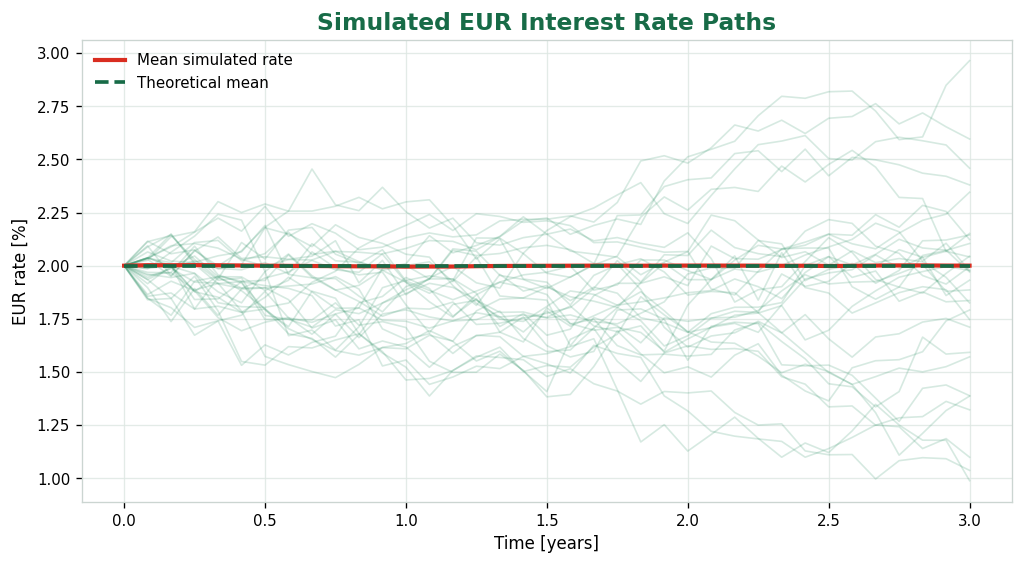

In [40]:
plt.figure(figsize=(10, 5))

for path_id in range(30):
    plt.plot(
        time_grid,
        ir_paths[path_id] * 100,
        color=chart_colors["green"],
        alpha=0.18,
        linewidth=1.0
    )

plt.plot(
    time_grid,
    ir_empirical_mean * 100,
    color=chart_colors["red"],
    linewidth=2.5,
    label="Mean simulated rate"
)

plt.plot(
    time_grid,
    ir_theoretical_mean * 100,
    color=chart_colors["green_dark"],
    linewidth=2.2,
    linestyle="--",
    label="Theoretical mean"
)

plt.xlabel("Time [years]")
plt.ylabel("EUR rate [%]")
plt.title("Simulated EUR Interest Rate Paths", color=chart_colors["green_dark"])
plt.legend()
plt.show()

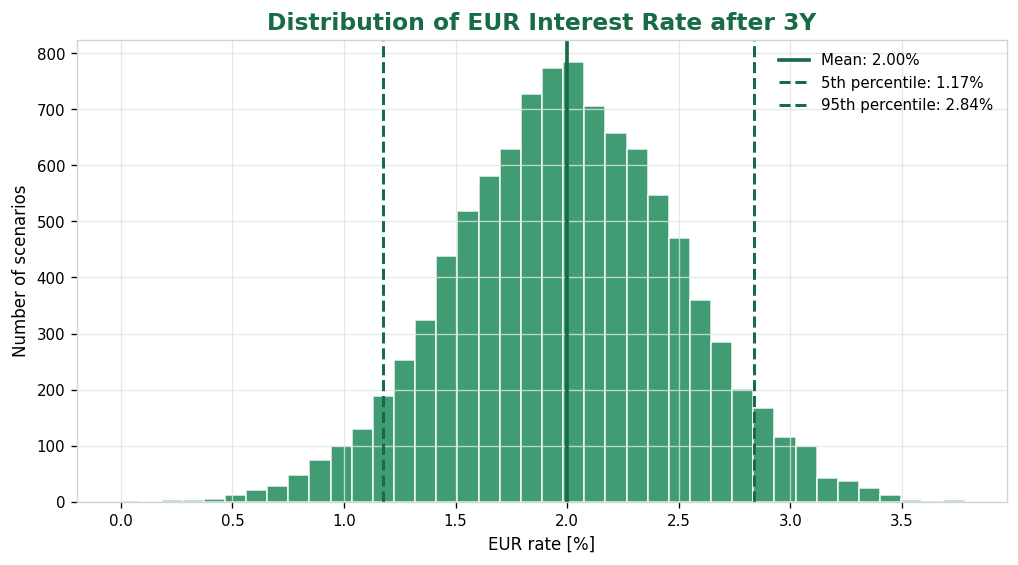

In [41]:
terminal_rates = ir_paths[:, -1] * 100

terminal_rate_mean = np.mean(terminal_rates)
terminal_rate_p05 = np.percentile(terminal_rates, 5)
terminal_rate_p95 = np.percentile(terminal_rates, 95)

plt.figure(figsize=(10, 5))

plt.hist(
    terminal_rates,
    bins=40,
    color=chart_colors["green"],
    alpha=0.85,
    edgecolor="white"
)

plt.axvline(
    terminal_rate_mean,
    color=chart_colors["green_dark"],
    linewidth=2.2,
    label=f"Mean: {terminal_rate_mean:.2f}%"
)

plt.axvline(
    terminal_rate_p05,
    color=chart_colors["green_dark"],
    linewidth=1.8,
    linestyle="--",
    label=f"5th percentile: {terminal_rate_p05:.2f}%"
)

plt.axvline(
    terminal_rate_p95,
    color=chart_colors["green_dark"],
    linewidth=1.8,
    linestyle="--",
    label=f"95th percentile: {terminal_rate_p95:.2f}%"
)

plt.xlabel("EUR rate [%]")
plt.ylabel("Number of scenarios")
plt.title("Distribution of EUR Interest Rate after 3Y", color=chart_colors["green_dark"])
plt.legend()
plt.show()

### Harmonogram przepływów IRS

Receiver IRS ma następującą strukturę przepływów:

- fixed leg: płatny rocznie w latach 1Y, 2Y, 3Y,
- floating leg: płatny kwartalnie w terminach 0.25Y, 0.50Y, ..., 3.00Y.

Dla receiver IRS:

$$
MtM_{IRS}(t)=PV_{fixed}(t)-PV_{floating}(t)
$$

Przepływy fixed:

$$
CF^{fixed}_i=N\cdot K\cdot\Delta_i
$$

Przepływy floating:

$$
CF^{float}_i=N\cdot L_i\cdot\Delta_i
$$


In [42]:
irs_fixed_payment_dates = np.array([1.0, 2.0, 3.0])
irs_float_payment_dates = np.arange(0.25, irs_maturity_years + 0.25, 0.25)

irs_fixed_accrual = 1.0
irs_float_accrual = 0.25

def time_to_grid_index(time_value, simulation_step_years):
    return int(round(time_value / simulation_step_years))

pd.DataFrame({
    "cashflow_type": (
        ["Fixed leg"] * len(irs_fixed_payment_dates)
        + ["Floating leg"] * len(irs_float_payment_dates)
    ),
    "payment_time": np.concatenate([
        irs_fixed_payment_dates,
        irs_float_payment_dates
    ])
})

,cashflow_type,payment_time
0,Fixed leg,1.000000
1,Fixed leg,2.000000
2,Fixed leg,3.000000
3,Floating leg,0.250000
4,Floating leg,0.500000
5,Floating leg,0.750000
6,Floating leg,1.000000
7,Floating leg,1.250000
8,Floating leg,1.500000
9,Floating leg,1.750000


In [43]:
def price_receiver_irs_cashflow_based_eur(
    path_id,
    valuation_month,
    ir_paths,
    notional_eur,
    fixed_rate,
    fixed_payment_dates,
    float_payment_dates,
    fixed_accrual,
    float_accrual,
    simulation_step_years
):
    valuation_time = valuation_month * simulation_step_years
    eps = 1e-10

    fixed_leg_pv = 0.0
    floating_leg_pv = 0.0

    current_rate = ir_paths[path_id, valuation_month]

    for payment_time in fixed_payment_dates:
        if payment_time > valuation_time + eps:
            time_to_payment = payment_time - valuation_time
            discount_factor = np.exp(-current_rate * time_to_payment)
            fixed_cashflow = notional_eur * fixed_rate * fixed_accrual
            fixed_leg_pv += fixed_cashflow * discount_factor

    for payment_time in float_payment_dates:
        fixing_time = payment_time - float_accrual

        if payment_time > valuation_time + eps:
            if fixing_time <= valuation_time + eps:
                fixing_month = time_to_grid_index(fixing_time, simulation_step_years)
                fixing_month = max(fixing_month, 0)
                fixing_month = min(fixing_month, ir_paths.shape[1] - 1)
                floating_rate = ir_paths[path_id, fixing_month]
            else:
                floating_rate = current_rate

            time_to_payment = payment_time - valuation_time
            discount_factor = np.exp(-current_rate * time_to_payment)
            floating_cashflow = notional_eur * floating_rate * float_accrual
            floating_leg_pv += floating_cashflow * discount_factor

    mtm_eur = fixed_leg_pv - floating_leg_pv

    return mtm_eur

In [44]:
irs_cashflow_mtm_test_eur = price_receiver_irs_cashflow_based_eur(
    path_id=0,
    valuation_month=0,
    ir_paths=ir_paths,
    notional_eur=irs_notional_eur,
    fixed_rate=irs_fixed_rate,
    fixed_payment_dates=irs_fixed_payment_dates,
    float_payment_dates=irs_float_payment_dates,
    fixed_accrual=irs_fixed_accrual,
    float_accrual=irs_float_accrual,
    simulation_step_years=simulation_step_years
)

pd.DataFrame({
    "metric": [
        "Old simplified IRS MtM EUR",
        "Cashflow-based IRS MtM EUR",
        "Difference"
    ],
    "value": [
        irs_mtm_0_eur,
        irs_cashflow_mtm_test_eur,
        irs_cashflow_mtm_test_eur - irs_mtm_0_eur
    ]
})

,metric,value
0,Old simplified IRS MtM EUR,-38.629657
1,Cashflow-based IRS MtM EUR,"1,416.043765"
2,Difference,"1,454.673422"


### Pathwise IRS MtM i ekspozycja

Dla każdego scenariusza i miesiąca liczony jest MtM IRS w EUR. Następnie wartość jest przeliczana na PLN z użyciem tej samej ścieżki FX:

$$
MtM^{PLN}_{IRS}(t)=MtM^{EUR}_{IRS}(t)\cdot S_t
$$

Ekspozycja IRS:

$$
E_{IRS}(t)=\max(MtM^{PLN}_{IRS}(t),0)
$$

Użycie pathwise FX jest konieczne, ponieważ CVA portfelowe ma być prezentowane w PLN.


In [45]:
irs_mtm_paths_eur = np.zeros_like(ir_paths)

for month in range(simulation_months + 1):
    for path_id in range(n_simulations):
        irs_mtm_paths_eur[path_id, month] = price_receiver_irs_cashflow_based_eur(
            path_id=path_id,
            valuation_month=month,
            ir_paths=ir_paths,
            notional_eur=irs_notional_eur,
            fixed_rate=irs_fixed_rate,
            fixed_payment_dates=irs_fixed_payment_dates,
            float_payment_dates=irs_float_payment_dates,
            fixed_accrual=irs_fixed_accrual,
            float_accrual=irs_float_accrual,
            simulation_step_years=simulation_step_years
        )

irs_exposure_paths_eur = np.maximum(irs_mtm_paths_eur, 0.0)

pd.DataFrame({
    "metric": [
        "Initial IRS MtM EUR",
        "Initial IRS Exposure EUR",
        "Final mean IRS MtM EUR",
        "Final mean IRS Exposure EUR"
    ],
    "value": [
        irs_mtm_paths_eur[:, 0].mean(),
        irs_exposure_paths_eur[:, 0].mean(),
        irs_mtm_paths_eur[:, -1].mean(),
        irs_exposure_paths_eur[:, -1].mean()
    ]
})

,metric,value
0,Initial IRS MtM EUR,"1,416.043765"
1,Initial IRS Exposure EUR,"1,416.043765"
2,Final mean IRS MtM EUR,0.000000
3,Final mean IRS Exposure EUR,0.000000


In [46]:
irs_mtm_paths_pln_standalone = irs_mtm_paths_eur * fx_paths
irs_exposure_paths_pln = np.maximum(irs_mtm_paths_pln_standalone, 0.0)

irs_ee_profile_pln = irs_exposure_paths_pln.mean(axis=0)
irs_pfe_95_profile_pln = np.quantile(irs_exposure_paths_pln, 0.95, axis=0)
irs_pfe_99_profile_pln = np.quantile(irs_exposure_paths_pln, 0.99, axis=0)

irs_exposure_profile_pln = pd.DataFrame({
    "month": np.arange(0, simulation_months + 1),
    "time_years": time_grid,
    "expected_exposure_pln": irs_ee_profile_pln,
    "pfe_95_pln": irs_pfe_95_profile_pln,
    "pfe_99_pln": irs_pfe_99_profile_pln
})

irs_exposure_profile_pln.tail()

,month,time_years,expected_exposure_pln,pfe_95_pln,pfe_99_pln
32,32,2.666667,"445,499.218398","631,878.589972","714,807.023482"
33,33,2.750000,"668,022.539054","810,460.148276","883,079.652977"
34,34,2.833333,"670,086.174050","815,321.167695","889,174.870951"
35,35,2.916667,"671,987.183436","819,567.079780","892,938.404351"
36,36,3.000000,0.000000,0.000000,0.000000


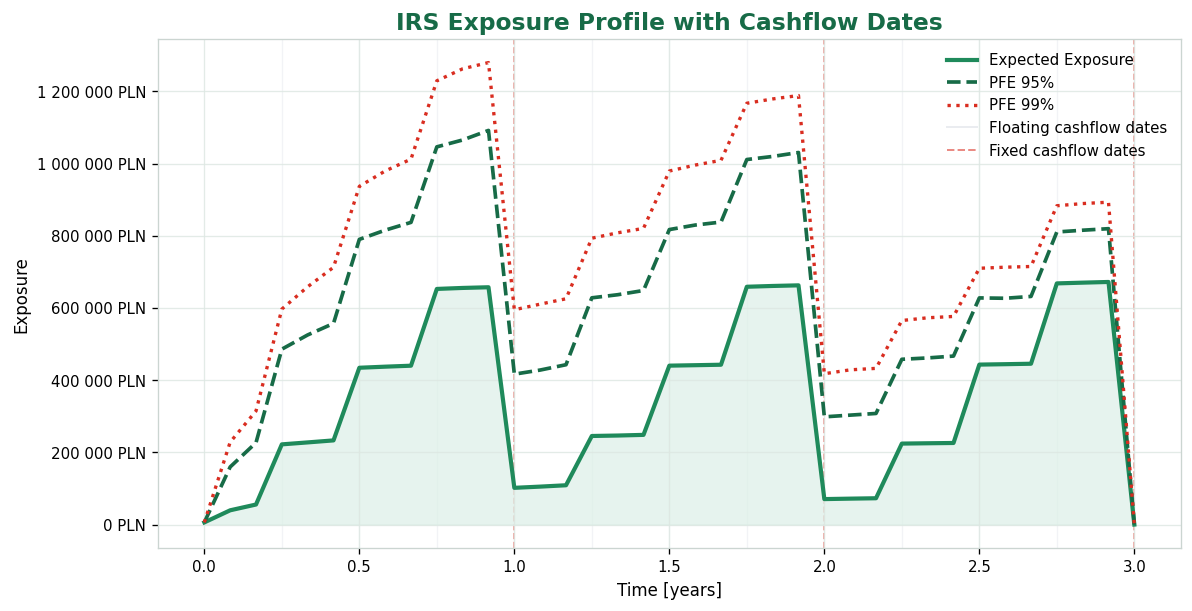

In [47]:
plt.figure(figsize=(11, 5.5))

for payment_time in irs_float_payment_dates:
    plt.axvline(
        payment_time,
        color=chart_colors["grey_light"],
        linewidth=0.8,
        alpha=0.6,
        zorder=0
    )

for payment_time in irs_fixed_payment_dates:
    plt.axvline(
        payment_time,
        color=chart_colors["red"],
        linewidth=1.0,
        linestyle="--",
        alpha=0.45,
        zorder=0
    )

ee_line, = plt.plot(
    irs_exposure_profile_pln["time_years"],
    irs_exposure_profile_pln["expected_exposure_pln"],
    color=chart_colors["green"],
    linewidth=2.5,
    label="Expected Exposure"
)

pfe95_line, = plt.plot(
    irs_exposure_profile_pln["time_years"],
    irs_exposure_profile_pln["pfe_95_pln"],
    color=chart_colors["green_dark"],
    linewidth=2.2,
    linestyle="--",
    label="PFE 95%"
)

pfe99_line, = plt.plot(
    irs_exposure_profile_pln["time_years"],
    irs_exposure_profile_pln["pfe_99_pln"],
    color=chart_colors["red"],
    linewidth=2.0,
    linestyle=":",
    label="PFE 99%"
)

plt.fill_between(
    irs_exposure_profile_pln["time_years"],
    irs_exposure_profile_pln["expected_exposure_pln"],
    0,
    color=chart_colors["green_light"],
    alpha=0.7
)

floating_cf_legend = Line2D(
    [0],
    [0],
    color=chart_colors["grey_light"],
    linewidth=1.2,
    label="Floating cashflow dates"
)

fixed_cf_legend = Line2D(
    [0],
    [0],
    color=chart_colors["red"],
    linewidth=1.2,
    linestyle="--",
    alpha=0.55,
    label="Fixed cashflow dates"
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f} PLN".replace(",", " "))
)

plt.xlabel("Time [years]")
plt.ylabel("Exposure")
plt.title("IRS Exposure Profile with Cashflow Dates", color=chart_colors["green_dark"])

plt.legend(
    handles=[
        ee_line,
        pfe95_line,
        pfe99_line,
        floating_cf_legend,
        fixed_cf_legend
    ],
    loc="upper right"
)

plt.show()

In [48]:
irs_exposure_key_points = irs_exposure_profile_pln.loc[
    irs_exposure_profile_pln["month"].isin([6, 12, 24, 36]),
    [
        "month",
        "time_years",
        "expected_exposure_pln",
        "pfe_95_pln",
        "pfe_99_pln"
    ]
].copy()

irs_exposure_key_points

,month,time_years,expected_exposure_pln,pfe_95_pln,pfe_99_pln
6,6,0.500000,"434,357.440641","789,933.485977","936,807.313542"
12,12,1.000000,"101,759.396612","416,591.623737","594,980.233803"
24,24,2.000000,"70,558.689190","298,395.537735","417,819.506105"
36,36,3.000000,0.000000,0.000000,0.000000


## 7. CVA standalone, portfolio netting i Variation Margin

CVA jest liczone zgodnie z dyskretną aproksymacją:

$$
CVA \approx (1-R)\sum_{i=1}^{N}EE(t_i)\cdot DF(0,t_i)\cdot q(t_{i-1},t_i)
$$

gdzie:

$$
q(t_{i-1},t_i)=PS(t_{i-1})-PS(t_i)
$$

Kalkulacja wykonywana jest dla:

- FX Forward standalone,
- IRS standalone,
- portfela bez VM,
- portfela z miesięczną Variation Margin.


In [49]:
cva_inputs = survival_table.loc[
    survival_table["month"].between(1, simulation_months),
    [
        "month",
        "time_years",
        "survival_probability",
        "marginal_default_probability",
        "cumulative_default_probability"
    ]
].copy()

cva_inputs["pln_df"] = cva_inputs["time_years"].apply(
    lambda t: float(pln_df_curve(t))
)

cva_inputs["lgd"] = lgd

cva_inputs = cva_inputs[
    [
        "month",
        "time_years",
        "survival_probability",
        "marginal_default_probability",
        "cumulative_default_probability",
        "pln_df",
        "lgd"
    ]
].copy()

cva_inputs.head()

,month,time_years,survival_probability,marginal_default_probability,cumulative_default_probability,pln_df,lgd
1,1,0.083333,0.999577,0.000423,0.000423,0.996880,0.600000
2,2,0.166667,0.999155,0.000422,0.000845,0.993769,0.600000
3,3,0.250000,0.998733,0.000422,0.001267,0.990669,0.600000
4,4,0.333333,0.998311,0.000422,0.001689,0.987578,0.600000
5,5,0.416667,0.997889,0.000422,0.002111,0.984496,0.600000


In [50]:
def calculate_cva(exposure_profile, cva_inputs, exposure_column):
    cva_table = cva_inputs.copy()

    exposure_data = exposure_profile[["month", exposure_column]].copy()

    cva_table = cva_table.merge(
        exposure_data,
        on="month",
        how="left"
    )

    cva_table[exposure_column] = cva_table[exposure_column].fillna(0.0)

    cva_table["cva_contribution"] = (
        cva_table["lgd"]
        * cva_table[exposure_column]
        * cva_table["pln_df"]
        * cva_table["marginal_default_probability"]
    )

    cva_value = cva_table["cva_contribution"].sum()

    return cva_value, cva_table

In [51]:
fx_cva, fx_cva_table = calculate_cva(
    exposure_profile=fx_exposure_profile,
    cva_inputs=cva_inputs,
    exposure_column="expected_exposure"
)

irs_cva, irs_cva_table = calculate_cva(
    exposure_profile=irs_exposure_profile_pln,
    cva_inputs=cva_inputs,
    exposure_column="expected_exposure_pln"
)

standalone_cva_summary = pd.DataFrame({
    "instrument": [
        "FX Forward",
        "Receiver IRS"
    ],
    "cva_pln": [
        fx_cva,
        irs_cva
    ]
})

standalone_cva_summary

,instrument,cva_pln
0,FX Forward,"3,695.582553"
1,Receiver IRS,"9,438.765717"


### Portfel bez Variation Margin

Na poziomie portfela uwzględniamy netting między FX Forward i IRS. Pathwise MtM portfela w PLN:

$$
MtM_{portfolio}(t)=MtM_{FX}(t)+MtM^{EUR}_{IRS}(t)\cdot S_t
$$

Ekspozycja portfelowa bez collateralizacji:

$$
E_{portfolio}(t)=\max(MtM_{portfolio}(t),0)
$$

Netting benefit wynika z tego, że dodatnia ekspozycja jednego instrumentu może być częściowo kompensowana ujemnym MtM drugiego instrumentu.


In [52]:
irs_mtm_paths_pln = irs_mtm_paths_eur * fx_paths

portfolio_mtm_paths_pln = (
    fx_forward_mtm_paths
    + irs_mtm_paths_pln
)

portfolio_exposure_paths_pln = np.maximum(
    portfolio_mtm_paths_pln,
    0.0
)

portfolio_ee_profile = portfolio_exposure_paths_pln.mean(axis=0)
portfolio_pfe_95_profile = np.quantile(portfolio_exposure_paths_pln, 0.95, axis=0)
portfolio_pfe_99_profile = np.quantile(portfolio_exposure_paths_pln, 0.99, axis=0)

portfolio_exposure_profile = pd.DataFrame({
    "month": np.arange(0, simulation_months + 1),
    "time_years": time_grid,
    "expected_exposure_pln": portfolio_ee_profile,
    "pfe_95_pln": portfolio_pfe_95_profile,
    "pfe_99_pln": portfolio_pfe_99_profile
})

portfolio_exposure_profile.tail()

,month,time_years,expected_exposure_pln,pfe_95_pln,pfe_99_pln
32,32,2.666667,"480,742.543250","1,276,113.363645","1,694,582.224514"
33,33,2.750000,"680,198.312205","1,550,307.416869","2,000,717.440081"
34,34,2.833333,"683,282.218959","1,572,801.587841","2,038,513.988975"
35,35,2.916667,"685,145.276788","1,589,165.485324","2,065,322.964266"
36,36,3.000000,"183,059.828254","809,843.533109","1,232,836.410613"


In [53]:
portfolio_cva, portfolio_cva_table = calculate_cva(
    exposure_profile=portfolio_exposure_profile,
    cva_inputs=cva_inputs,
    exposure_column="expected_exposure_pln"
)

cva_summary_no_vm = pd.DataFrame({
    "metric": [
        "FX Forward standalone CVA",
        "IRS standalone CVA",
        "Sum of standalone CVAs",
        "Portfolio CVA without VM",
        "Netting benefit"
    ],
    "value_pln": [
        fx_cva,
        irs_cva,
        fx_cva + irs_cva,
        portfolio_cva,
        fx_cva + irs_cva - portfolio_cva
    ]
})

cva_summary_no_vm

,metric,value_pln
0,FX Forward standalone CVA,"3,695.582553"
1,IRS standalone CVA,"9,438.765717"
2,Sum of standalone CVAs,"13,134.348270"
3,Portfolio CVA without VM,"10,590.014207"
4,Netting benefit,"2,544.334063"


### Portfel z Variation Margin

Variation Margin jest denominowana w PLN i wymieniana miesięcznie. Zgodnie z założeniem projektowym VM dla kroku $T$ bazuje na MtM portfela z poprzedniego kroku:

$$
VM(T)=MtM_{IRS}(T-1)\cdot FX(T-1)+MtM_{FX}(T-1)
$$

oraz:

$$
VM(0)=0
$$

Ekspozycja rezydualna po VM:

$$
E^{VM}_{portfolio}(T)=\max(MtM_{portfolio}(T)-VM(T),0)
$$

Ważne: VM jest liczona od pełnego pathwise MtM portfela, a nie od samego EE ani od dodatniej ekspozycji. Dzięki temu zachowujemy poprawną interpretację collateralizacji.


In [54]:
portfolio_vm_paths_pln = np.zeros_like(portfolio_mtm_paths_pln)

portfolio_vm_paths_pln[:, 1:] = portfolio_mtm_paths_pln[:, :-1]

portfolio_residual_mtm_paths_pln = (
    portfolio_mtm_paths_pln
    - portfolio_vm_paths_pln
)

portfolio_exposure_vm_paths_pln = np.maximum(
    portfolio_residual_mtm_paths_pln,
    0.0
)

portfolio_ee_vm_profile = portfolio_exposure_vm_paths_pln.mean(axis=0)
portfolio_pfe_95_vm_profile = np.quantile(portfolio_exposure_vm_paths_pln, 0.95, axis=0)
portfolio_pfe_99_vm_profile = np.quantile(portfolio_exposure_vm_paths_pln, 0.99, axis=0)

portfolio_exposure_vm_profile = pd.DataFrame({
    "month": np.arange(0, simulation_months + 1),
    "time_years": time_grid,
    "expected_exposure_pln": portfolio_ee_vm_profile,
    "pfe_95_pln": portfolio_pfe_95_vm_profile,
    "pfe_99_pln": portfolio_pfe_99_vm_profile
})

portfolio_exposure_vm_profile.tail()

,month,time_years,expected_exposure_pln,pfe_95_pln,pfe_99_pln
32,32,2.666667,"34,703.790806","142,514.689874","203,533.110527"
33,33,2.750000,"223,493.205281","403,135.857761","479,824.189030"
34,34,2.833333,"36,575.941316","147,821.538737","215,428.249732"
35,35,2.916667,"36,381.799503","150,229.347520","213,306.792281"
36,36,3.000000,0.000000,0.000000,0.000000


In [55]:
portfolio_cva_vm, portfolio_cva_vm_table = calculate_cva(
    exposure_profile=portfolio_exposure_vm_profile,
    cva_inputs=cva_inputs,
    exposure_column="expected_exposure_pln"
)

cva_summary_with_vm = pd.DataFrame({
    "metric": [
        "Portfolio CVA without VM",
        "Portfolio CVA with VM",
        "VM benefit"
    ],
    "value_pln": [
        portfolio_cva,
        portfolio_cva_vm,
        portfolio_cva - portfolio_cva_vm
    ]
})

cva_summary_with_vm

,metric,value_pln
0,Portfolio CVA without VM,"10,590.014207"
1,Portfolio CVA with VM,"2,087.494367"
2,VM benefit,"8,502.519840"


### Podsumowanie wyników CVA

Końcowe zestawienie pokazuje wpływ nettingu i Variation Margin na CVA. Wiersz „Portfolio without VM” izoluje efekt nettingu, a wiersz „Portfolio with VM” pokazuje łączny efekt nettingu oraz miesięcznej collateralizacji.


In [56]:
sum_standalone_cva = fx_cva + irs_cva

final_cva_summary = pd.DataFrame({
    "case": [
        "FX Forward standalone",
        "Receiver IRS standalone",
        "Sum of standalone CVAs",
        "Portfolio without VM",
        "Portfolio with VM"
    ],
    "cva_pln": [
        fx_cva,
        irs_cva,
        sum_standalone_cva,
        portfolio_cva,
        portfolio_cva_vm
    ]
})

final_cva_summary["reduction_vs_sum_standalone_pln"] = (
    sum_standalone_cva - final_cva_summary["cva_pln"]
)

final_cva_summary["reduction_vs_sum_standalone_pct"] = (
    final_cva_summary["reduction_vs_sum_standalone_pln"]
    / sum_standalone_cva
)

final_cva_summary.loc[
    final_cva_summary["case"].isin([
        "FX Forward standalone",
        "Receiver IRS standalone"
    ]),
    [
        "reduction_vs_sum_standalone_pln",
        "reduction_vs_sum_standalone_pct"
    ]
] = np.nan

final_cva_summary

,case,cva_pln,reduction_vs_sum_standalone_pln,reduction_vs_sum_standalone_pct
0,FX Forward standalone,"3,695.582553",NaN,NaN
1,Receiver IRS standalone,"9,438.765717",NaN,NaN
2,Sum of standalone CVAs,"13,134.348270",0.000000,0.000000
3,Portfolio without VM,"10,590.014207","2,544.334063",0.193716
4,Portfolio with VM,"2,087.494367","11,046.853903",0.841066


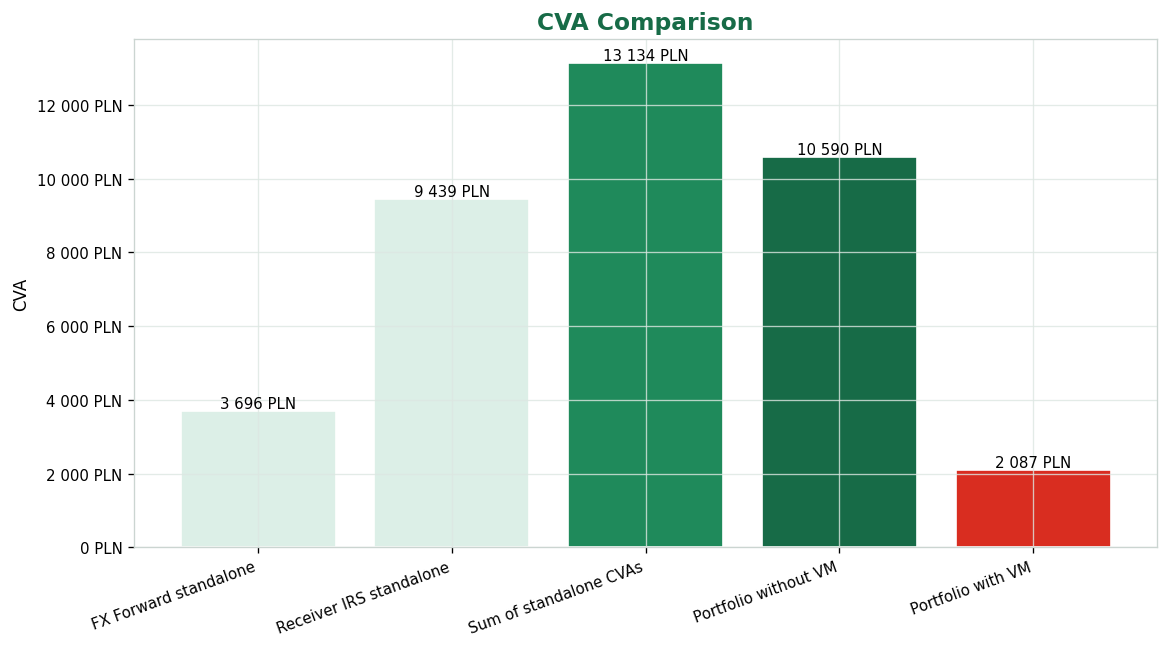

In [57]:
cva_plot_data = final_cva_summary.loc[
    final_cva_summary["case"].isin([
        "FX Forward standalone",
        "Receiver IRS standalone",
        "Sum of standalone CVAs",
        "Portfolio without VM",
        "Portfolio with VM"
    ]),
    ["case", "cva_pln"]
].copy()

plt.figure(figsize=(11, 5.5))

bars = plt.bar(
    cva_plot_data["case"],
    cva_plot_data["cva_pln"],
    color=[
        chart_colors["green_light"],
        chart_colors["green_light"],
        chart_colors["green"],
        chart_colors["green_dark"],
        chart_colors["red"]
    ],
    edgecolor="white"
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f} PLN".replace(",", " "))
)

plt.xticks(rotation=20, ha="right")
plt.ylabel("CVA")
plt.title("CVA Comparison", color=chart_colors["green_dark"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f} PLN".replace(",", " "),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

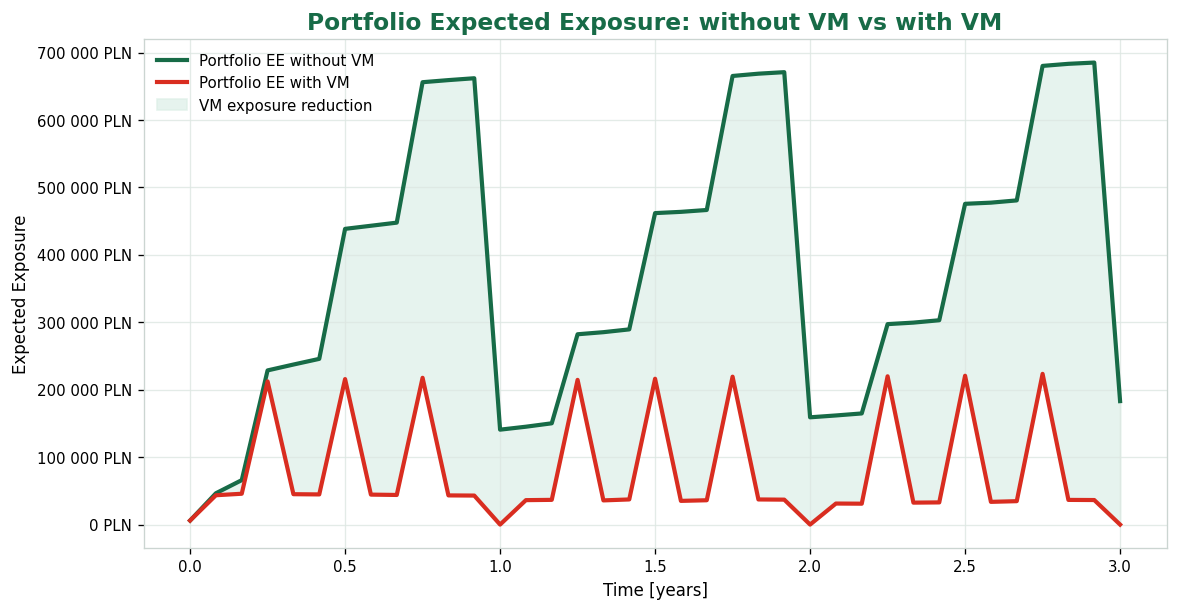

In [58]:
plt.figure(figsize=(11, 5.5))

plt.plot(
    portfolio_exposure_profile["time_years"],
    portfolio_exposure_profile["expected_exposure_pln"],
    color=chart_colors["green_dark"],
    linewidth=2.5,
    label="Portfolio EE without VM"
)

plt.plot(
    portfolio_exposure_vm_profile["time_years"],
    portfolio_exposure_vm_profile["expected_exposure_pln"],
    color=chart_colors["red"],
    linewidth=2.5,
    label="Portfolio EE with VM"
)

plt.fill_between(
    portfolio_exposure_profile["time_years"],
    portfolio_exposure_profile["expected_exposure_pln"],
    portfolio_exposure_vm_profile["expected_exposure_pln"],
    color=chart_colors["green_light"],
    alpha=0.7,
    label="VM exposure reduction"
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f} PLN".replace(",", " "))
)

plt.xlabel("Time [years]")
plt.ylabel("Expected Exposure")
plt.title("Portfolio Expected Exposure: without VM vs with VM", color=chart_colors["green_dark"])
plt.legend()
plt.show()

In [59]:
portfolio_ee_comparison_key_points = portfolio_exposure_profile.loc[
    portfolio_exposure_profile["month"].isin([6, 12, 24, 36]),
    ["month", "time_years", "expected_exposure_pln"]
].copy()

portfolio_ee_comparison_key_points = portfolio_ee_comparison_key_points.rename(
    columns={"expected_exposure_pln": "ee_without_vm_pln"}
)

portfolio_ee_comparison_key_points = portfolio_ee_comparison_key_points.merge(
    portfolio_exposure_vm_profile.loc[
        portfolio_exposure_vm_profile["month"].isin([6, 12, 24, 36]),
        ["month", "expected_exposure_pln"]
    ].rename(columns={"expected_exposure_pln": "ee_with_vm_pln"}),
    on="month",
    how="left"
)

portfolio_ee_comparison_key_points["ee_reduction_pln"] = (
    portfolio_ee_comparison_key_points["ee_without_vm_pln"]
    - portfolio_ee_comparison_key_points["ee_with_vm_pln"]
)

portfolio_ee_comparison_key_points["ee_reduction_pct"] = (
    portfolio_ee_comparison_key_points["ee_reduction_pln"]
    / portfolio_ee_comparison_key_points["ee_without_vm_pln"]
)

portfolio_ee_comparison_key_points

,month,time_years,ee_without_vm_pln,ee_with_vm_pln,ee_reduction_pln,ee_reduction_pct
0,6,0.500000,"438,536.972504","215,785.201289","222,751.771216",0.507943
1,12,1.000000,"140,745.196231",0.000000,"140,745.196231",1.000000
2,24,2.000000,"159,058.166919",0.000000,"159,058.166919",1.000000
3,36,3.000000,"183,059.828254",0.000000,"183,059.828254",1.000000
